If I were to study the conversation usage patterns, what would I be looking for?

- are people chatting with those they trade with?
    - [x] do they start chatting before or after they are trading?
        - does group size matter?
    - do stronger connections also have more messages sent?
        - compare intensity of positive influence to number (proportion?) of messages sent in the (previous?) round 
    - are individuals with stronger connections than the rest of the group likely to have sub group chats?
        - at what point do they break off if so?
- are people chatting with those they attack with?
    - does the intensity of the attack mean anything?
- [x] mental load/timing 
    - [x] how many chats does each person have?
    - [x] how fast do they respond?
    - [x] how often/fast do they switch between each conversation?
- How many conversations do people create?
    - in a round
    - total

- create a survey for people playing 
    - for each conversation you created, explain why you created it
    - for each conversation you stopped using, explain why you stopped using it

In [40]:
import json

def pull_chat_data_from_json(json_file):
    with open(json_file, 'r') as f:
        data = json.load(f)

        chat_data = {}

        for game_id, game_data in data.items():
            if 'chatInfo' in game_data:
                game_chat_data = game_data['chatInfo']
                chat_data[game_id] = game_chat_data
                
    return chat_data

chat_data = pull_chat_data_from_json('preprod_filtered.json')

In [41]:
def convert_str_to_time(time_str):
    from datetime import datetime
    # str will look like this 2026-09-21T18:13:54.619195Z
    return datetime.strptime(time_str, '%Y-%m-%dT%H:%M:%S.%fZ')

No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.


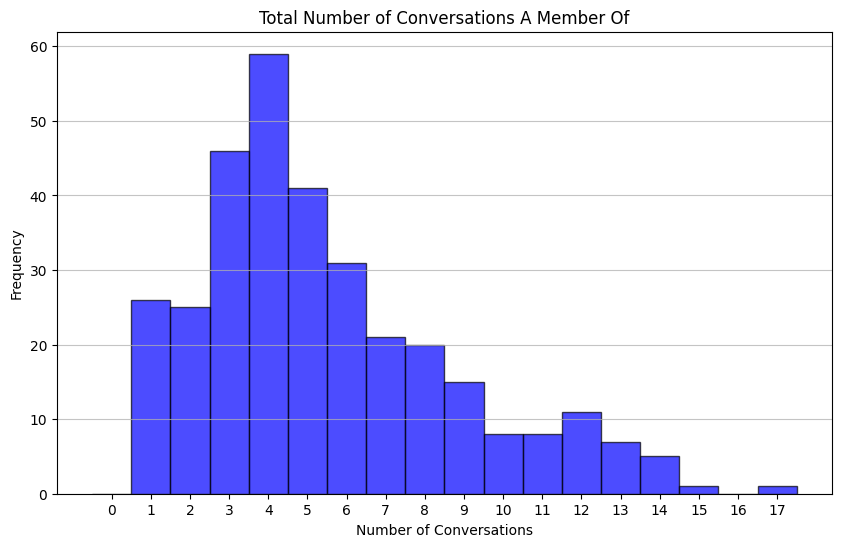

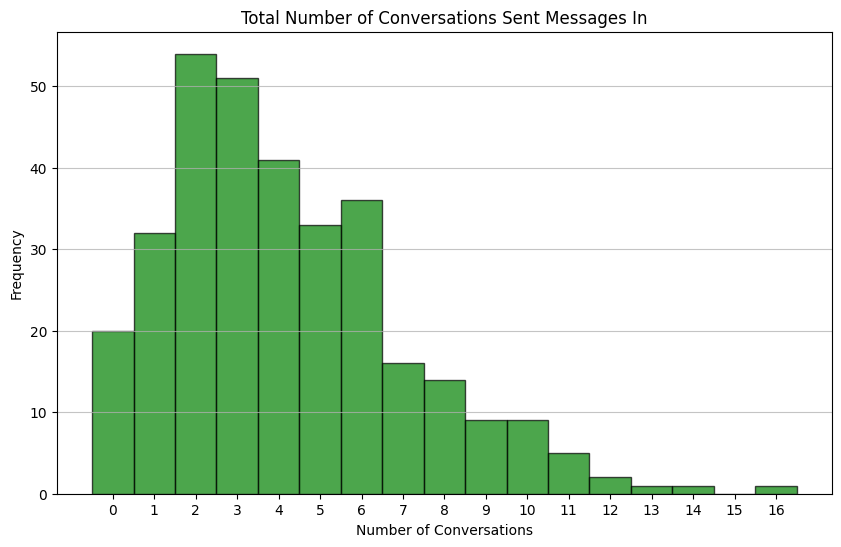

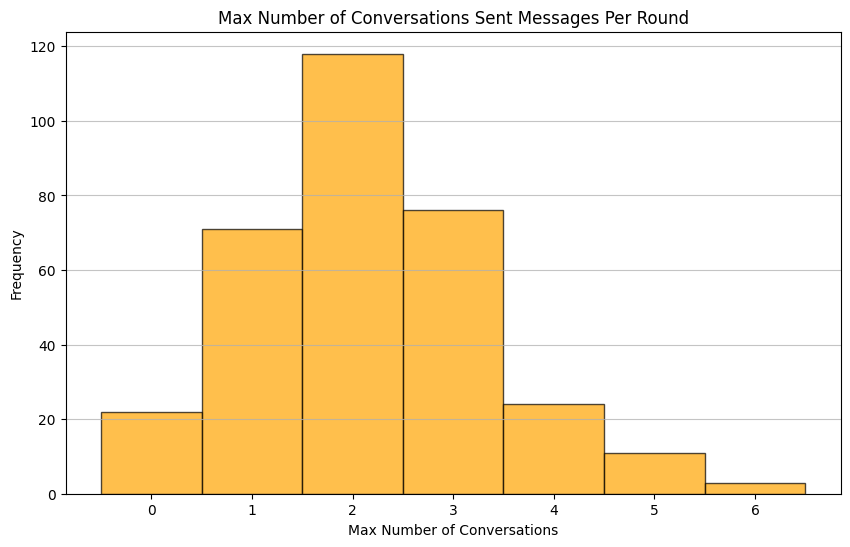

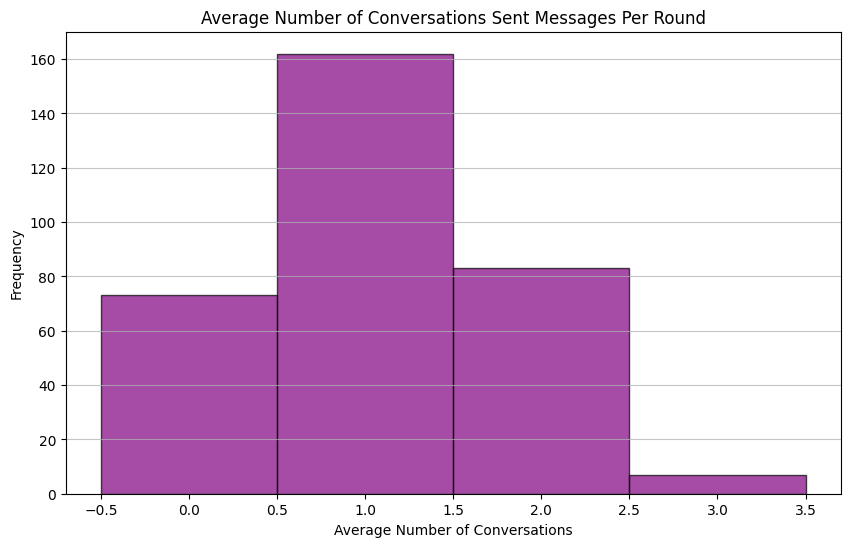

In [11]:
# How many chats are people a member of?
# How many chats do they send messages in total?
# How many chats do they send messages in per round?

def find_number_of_conversations_for_all_games(json_file):
    all_num_conversations_in = []
    all_num_conversations_sent_messages = []
    all_num_conversations_sent_messages_per_round = []
    all_avg_num_conversations_sent_messages_per_round = []
    all_max_num_conversations_sent_messages_per_round = []

    with open(json_file, 'r') as f:
        data = json.load(f)

        for game_id, game_data in data.items():
            players = game_data['privateInfo']['gameNames']

            chat_data = game_data['chatInfo']
            round_end_times = []
            for c_id, conversation in chat_data['conversations'].items():
                if c_id == 'global':
                    for m_id, message in conversation['messages'].items():
                        if message['runtimeType'] == 'gameNotification' or message['from'] == 'Game':
                            round_end_times.append(convert_str_to_time(message['time']))
            if len(round_end_times) == 0:
                print(f"No round end times found for game {game_id}. Skipping.")
                continue

            for player in players:
                num_conversations_in, num_conversations_sent_messages, num_conversations_sent_messages_per_round = find_number_of_conversations_for_player(chat_data, player, round_end_times)
                all_num_conversations_in.append(num_conversations_in)
                all_num_conversations_sent_messages.append(num_conversations_sent_messages)
                all_num_conversations_sent_messages_per_round.append(num_conversations_sent_messages_per_round)
                all_avg_num_conversations_sent_messages_per_round.append(sum(num_conversations_sent_messages_per_round) / len(num_conversations_sent_messages_per_round))
                all_max_num_conversations_sent_messages_per_round.append(max(num_conversations_sent_messages_per_round))
        
        display_charts(all_num_conversations_in, all_num_conversations_sent_messages, all_num_conversations_sent_messages_per_round, all_max_num_conversations_sent_messages_per_round, all_avg_num_conversations_sent_messages_per_round)

def display_charts(all_num_conversations_in, all_num_conversations_sent_messages, all_num_conversations_sent_messages_per_round, all_max_num_conversations_sent_messages_per_round, all_avg_num_conversations_sent_messages_per_round):
    import matplotlib.pyplot as plt

    # Plot number of conversations in
    plt.figure(figsize=(10, 6))
    bins = [i - 0.5 for i in range(max(all_num_conversations_in) + 2)]
    plt.hist(all_num_conversations_in, bins=bins, alpha=0.7, color='blue', edgecolor='black')
    plt.xticks(range(max(all_num_conversations_in) + 1))
    plt.title('Total Number of Conversations A Member Of')
    plt.xlabel('Number of Conversations')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Plot number of conversations sent messages
    plt.figure(figsize=(10, 6))
    bins = [i - 0.5 for i in range(max(all_num_conversations_sent_messages) + 2)]
    plt.hist(all_num_conversations_sent_messages, bins=bins, alpha=0.7, color='green', edgecolor='black')
    plt.xticks(range(max(all_num_conversations_sent_messages) + 1))
    plt.title('Total Number of Conversations Sent Messages In')
    plt.xlabel('Number of Conversations')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Plot max number of conversations sent messages per round
    plt.figure(figsize=(10, 6))
    bins = [i - 0.5 for i in range(max(all_max_num_conversations_sent_messages_per_round) + 2)]
    plt.hist(
        all_max_num_conversations_sent_messages_per_round,
        bins=bins,
        alpha=0.7,
        color='orange',
        edgecolor='black'
    )
    plt.xticks(range(max(all_max_num_conversations_sent_messages_per_round) + 1))
    plt.title('Max Number of Conversations Sent Messages Per Round')
    plt.xlabel('Max Number of Conversations')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Plot average number of conversations sent messages per round
    plt.figure(figsize=(10, 6))
    bins = [i - 0.5 for i in range(int(max(all_avg_num_conversations_sent_messages_per_round)) + 2)]
    plt.hist(
        all_avg_num_conversations_sent_messages_per_round,
        bins=bins,
        alpha=0.7,
        color='purple',
        edgecolor='black'
    )
    plt.title('Average Number of Conversations Sent Messages Per Round')
    plt.xlabel('Average Number of Conversations')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()  

def find_number_of_conversations_for_player(chat_data, player_name, round_end_times):
    num_conversations_in = 0
    num_conversations_sent_messages = 0
    num_conversations_sent_messages_per_round = [0 for _ in range(len(round_end_times))]

    for c_id, conversation in chat_data['conversations'].items():
        if c_id == 'global' or player_name in conversation['participants']:
            num_conversations_in += 1

            if 'messages' not in conversation:
                print(f"No messages found for conversation {c_id}. Skipping.")
                break

            for m_id, message in conversation['messages'].items():
                if message.get('from') == player_name:
                    num_conversations_sent_messages += 1
                    break  # Count only once per conversation

            round = 1

            for m_id, message in conversation['messages'].items():
                if round > len(round_end_times):
                    break  # message sent after the last round, ignore
                while convert_str_to_time(message['time']) >= round_end_times[round-1]:
                    round += 1
                    if round > len(round_end_times):
                        break  # message sent after the last round, ignore
                if round > len(round_end_times):
                    break  # message sent after the last round, ignore

                if message.get('from') == player_name:
                    if convert_str_to_time(message['time']) < round_end_times[round-1] and (round == 1 or convert_str_to_time(message['time']) > round_end_times[round-2]):
                        num_conversations_sent_messages_per_round[round - 1] += 1
                        round += 1

    return num_conversations_in, num_conversations_sent_messages, num_conversations_sent_messages_per_round
    
    
find_number_of_conversations_for_all_games('preprod_filtered.json')
    


No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.


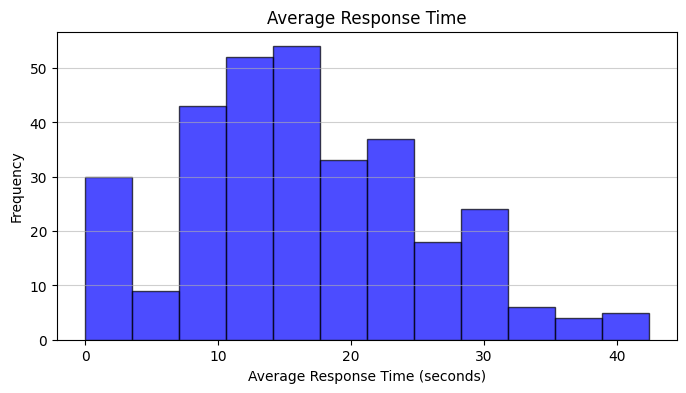

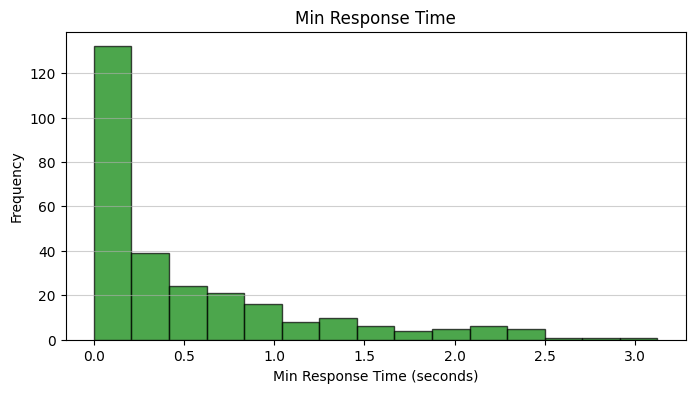

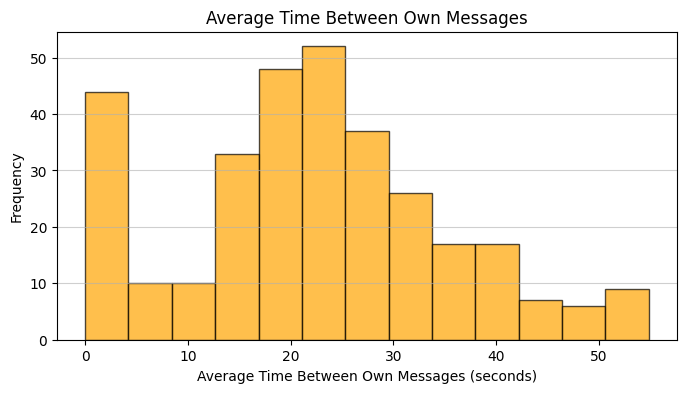

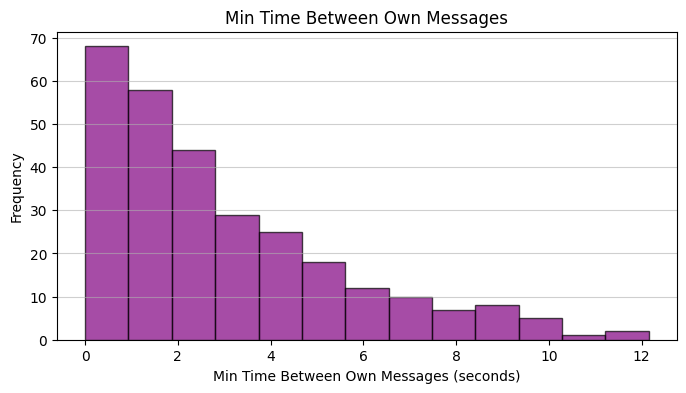

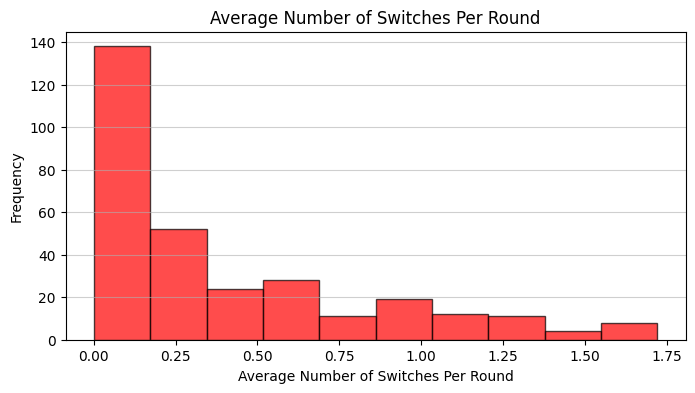

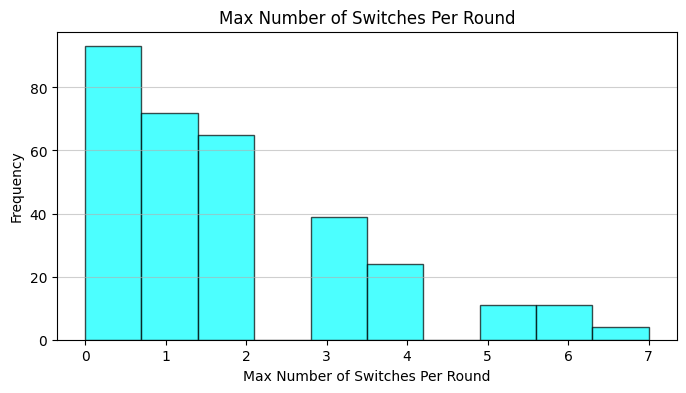

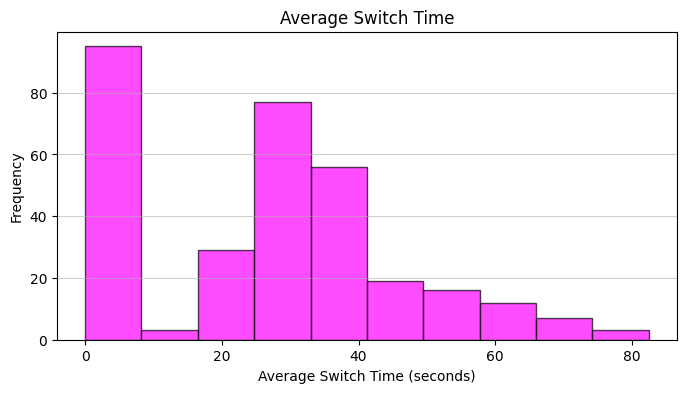

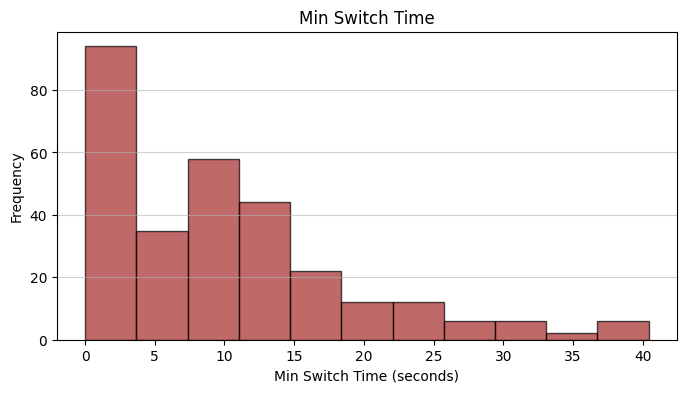

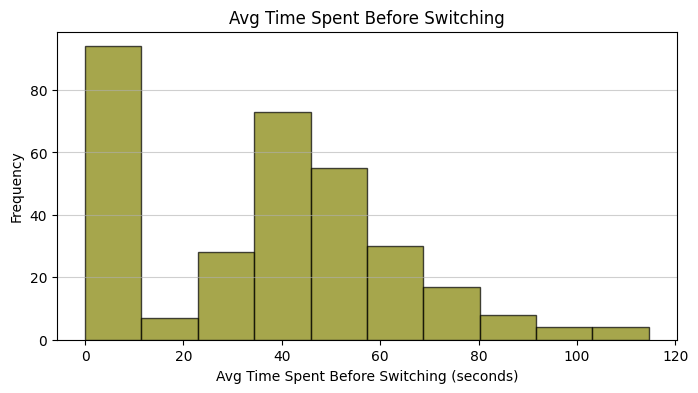

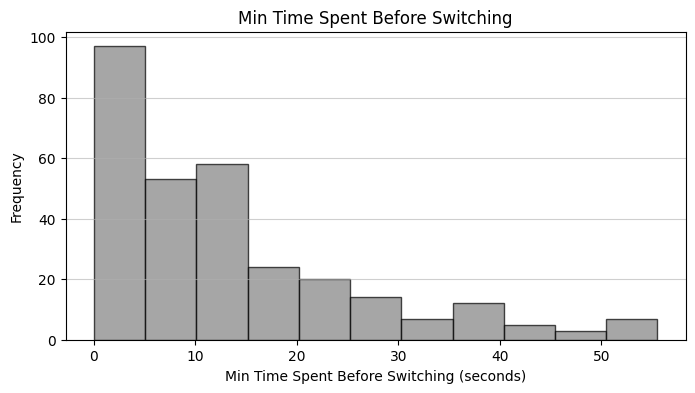

In [ ]:
# How quickly do people respond to messages in conversations?
# How quickly do people send messages in any conversation?
# How quickly do people switch between conversations?
# How many times do they switch conversations in a round?

import datetime

def find_number_of_conversations_for_all_games(json_file):
    all_avg_respond_time = []
    all_min_respond_time = []
    all_avg_message_time = []
    all_min_message_time = []
    all_avg_num_switches = []
    all_max_num_switches = []
    all_avg_switch_time = []
    all_min_switch_time = []
    all_avg_time_spent_before_switching = []
    all_min_time_spent_before_switching = []

    with open(json_file, 'r') as f:
        data = json.load(f)

        for game_id, game_data in data.items():
            players = game_data['privateInfo']['gameNames']

            chat_data = game_data['chatInfo']
            round_end_times = []
            for c_id, conversation in chat_data['conversations'].items():
                if c_id == 'global':
                    for m_id, message in conversation['messages'].items():
                        if message['runtimeType'] == 'gameNotification' or message['from'] == 'Game':
                            round_end_times.append(convert_str_to_time(message['time']))
            if len(round_end_times) == 0:
                print(f"No round end times found for game {game_id}. Skipping.")
                continue

            for player in players:
                avg_respond_time, min_respond_time, avg_message_time, min_message_time, avg_num_switches, max_num_switches, avg_switch_time, min_switch_time, avg_time_spent_before_switching, min_time_spent_before_switching = find_conversation_timing_for_player(chat_data, player, round_end_times)

                all_avg_respond_time.append(avg_respond_time)
                all_min_respond_time.append(min_respond_time)
                all_avg_message_time.append(avg_message_time)
                all_min_message_time.append(min_message_time)
                all_avg_num_switches.append(avg_num_switches)
                all_max_num_switches.append(max_num_switches)
                all_avg_switch_time.append(avg_switch_time)
                all_min_switch_time.append(min_switch_time)
                all_avg_time_spent_before_switching.append(avg_time_spent_before_switching)
                all_min_time_spent_before_switching.append(min_time_spent_before_switching)   
        
        display_charts(all_avg_respond_time, all_min_respond_time, all_avg_message_time, all_min_message_time, all_avg_num_switches, all_max_num_switches, all_avg_switch_time, all_min_switch_time, all_avg_time_spent_before_switching, all_min_time_spent_before_switching)

def find_conversation_timing_for_player(chat_data, player_name, round_end_times):
    respond_times = []
    message_times = []
    switch_times = []
    num_switches_per_round = [0 for _ in range(len(round_end_times))]
    time_spent_before_switching = []

    player_message_times_by_conversation = {}

    for c_id, conversation in chat_data['conversations'].items():
        if c_id == 'global' or player_name in conversation['participants']:
            if 'messages' not in conversation:
                print(f"No messages found for conversation {c_id}. Skipping.")
                break

            round = 1
            previous_message_time = None
            previous_self_message_time = None

            for m_id, message in conversation['messages'].items():
                if round > len(round_end_times):
                    break  # message sent after the last round, ignore
                while convert_str_to_time(message['time']) >= round_end_times[round-1]:
                    round += 1
                    previous_message_time = None 
                    previous_self_message_time = None
                    if round > len(round_end_times):
                        break  # message sent after the last round, ignore
                if round > len(round_end_times):
                    break  # message sent after the last round, ignore

                if message.get('from') == player_name:
                    player_message_times_by_conversation.setdefault(c_id, []).append(convert_str_to_time(message['time']))
                    if convert_str_to_time(message['time']) < round_end_times[round-1] and (round == 1 or convert_str_to_time(message['time']) > round_end_times[round-2]):
                        if previous_message_time is not None:
                            respond_time = convert_str_to_time(message['time']) - previous_message_time
                            if respond_time.total_seconds() < 0:
                                respond_time = datetime.timedelta(0)
                            respond_times.append(respond_time)
                        if previous_self_message_time is not None:
                            message_time = convert_str_to_time(message['time']) - previous_self_message_time
                            message_times.append(message_time)
                        previous_self_message_time = convert_str_to_time(message['time'])

                previous_message_time = convert_str_to_time(message['time'])

    # calculate the time to switch between conversations, and the number of switches per round
    for round in range(1, len(round_end_times) + 1):
        messages_in_round = []
        for c_id, c_message_times in player_message_times_by_conversation.items():
            for message_time in c_message_times:
                if round == 1:
                    if message_time < round_end_times[round-1]:
                        messages_in_round.append((message_time, c_id))
                else:
                    if round_end_times[round-2] < message_time < round_end_times[round-1]:
                        messages_in_round.append((message_time, c_id))
                    if message_time > round_end_times[round-1]:
                        break # break early since messages are sorted by time
        messages_in_round.sort(key=lambda x: x[0])  # sort by time

        last_conversation = None
        for message_time, c_id in messages_in_round:
            if last_conversation is None:
                first_message_in_conversation = message_time        
            if last_conversation is not None and last_conversation != c_id:
                switch_time = message_time - last_message_time
                switch_times.append(switch_time)
                num_switches_per_round[round-1] += 1
                time_spent_before_switching.append(message_time - first_message_in_conversation)
                first_message_in_conversation = message_time
            last_conversation = c_id
            last_message_time = message_time
            
    # calculate averages and minimums
    
    avg_respond_time = sum(respond_times, datetime.timedelta(0)) / len(respond_times) if respond_times else 0
    min_respond_time = min(respond_times) if respond_times else 0
    avg_message_time = sum(message_times, datetime.timedelta(0)) / len(message_times) if message_times else 0
    min_message_time = min(message_times) if message_times else 0
    avg_num_switches = sum(num_switches_per_round) / len(num_switches_per_round) if num_switches_per_round else 0
    max_num_switches = max(num_switches_per_round) if num_switches_per_round else 0
    avg_switch_time = sum(switch_times, datetime.timedelta(0)) / len(switch_times) if switch_times else 0
    min_switch_time = min(switch_times) if switch_times else 0
    avg_time_spent_before_switching = sum(time_spent_before_switching, datetime.timedelta(0)) / len(time_spent_before_switching) if time_spent_before_switching else 0
    min_time_spent_before_switching = min(time_spent_before_switching) if time_spent_before_switching else 0

    return  avg_respond_time, min_respond_time, avg_message_time, min_message_time, avg_num_switches, max_num_switches, avg_switch_time, min_switch_time, avg_time_spent_before_switching, min_time_spent_before_switching

def display_charts(all_avg_respond_time, all_min_respond_time, all_avg_message_time, all_min_message_time, all_avg_num_switches, all_max_num_switches, all_avg_switch_time, all_min_switch_time, all_avg_time_spent_before_switching, all_min_time_spent_before_switching):
    import matplotlib.pyplot as plt
    
    vars_to_plot = [
        (all_avg_respond_time, 'Average Response Time'),
        (all_min_respond_time, 'Min Response Time'),
        (all_avg_message_time, 'Average Time Between Own Messages'),
        (all_min_message_time, 'Min Time Between Own Messages'),
        (all_avg_num_switches, 'Average Number of Switches Per Round'),
        (all_max_num_switches, 'Max Number of Switches Per Round'),
        (all_avg_switch_time, 'Average Switch Time'),
        (all_min_switch_time, 'Min Switch Time'),
        (all_avg_time_spent_before_switching, 'Avg Time Spent Before Switching'),
        (all_min_time_spent_before_switching, 'Min Time Spent Before Switching'),
    ]

    colors = ['blue','green','orange','purple','red','cyan','magenta','brown','olive','gray']
    for (data, title), color in zip(vars_to_plot, colors):
        if not data:
            print(f"No data for '{title}', skipping.")
            continue

        # Convert timedelta objects to total seconds
        converted_data = [d.total_seconds() if isinstance(d, datetime.timedelta) else d for d in data]
        converted_data = sorted(converted_data)

        # Remove obvious outliers using the IQR rule
        if len(converted_data) >= 4:
            q1_idx = len(converted_data) // 4
            q3_idx = (3 * len(converted_data)) // 4
            q1 = converted_data[q1_idx]
            q3 = converted_data[q3_idx]
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            filtered_data = [x for x in converted_data if lower_bound <= x <= upper_bound]
        else:
            filtered_data = converted_data

        if not filtered_data:
            print(f"All data removed as outliers for '{title}', skipping.")
            continue

        plt.figure(figsize=(8, 4))
        plt.hist(filtered_data, bins='auto', color=color, edgecolor='black', alpha=0.7)
        plt.title(title)
        plt.xlabel(title + (' (seconds)' if any(isinstance(d, datetime.timedelta) for d in data) else ''))
        plt.ylabel('Frequency')
        plt.grid(axis='y', alpha=0.6)
        plt.show()
 
find_number_of_conversations_for_all_games('preprod_filtered.json')

No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.


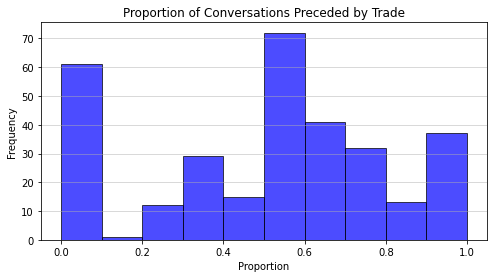

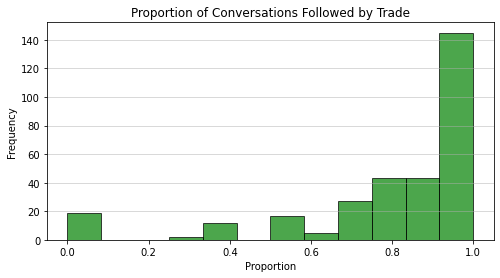

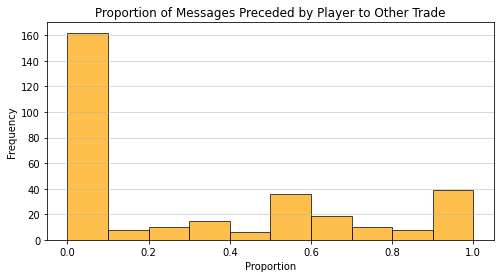

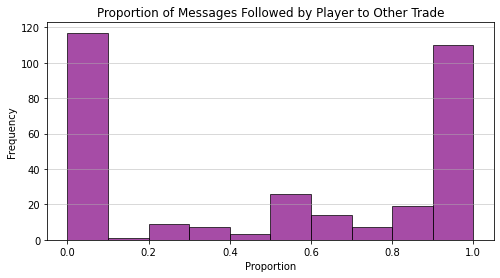

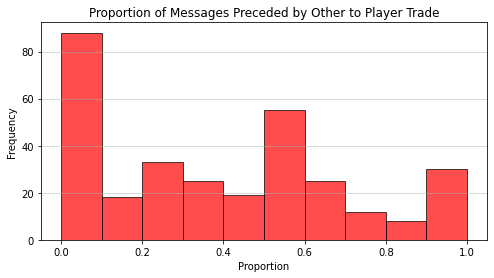

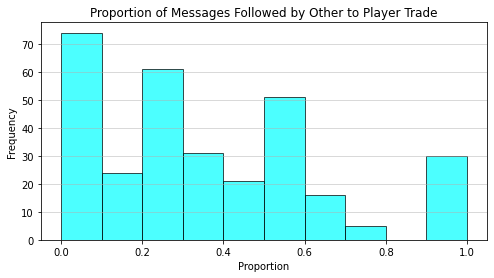

In [46]:
# - are people chatting with those they trade with?
#     - do they start chatting before or after they are trading?
#         - does group size matter?
#     - do stronger connections also have more messages sent?
#         - compare intensity of positive influence to number (proportion?) of messages sent in the (previous?) round 
#     - are individuals with stronger connections than the rest of the group likely to have sub group chats?
#         - at what point do they break off if so?
#           - maybe make a parameter to control this, like a threshold?

# What proportion of conversations are preceded by trade? (of the first round the conversation exists)
# What proportion of conversations are followed by trade? (of the first round)
# num messages vs. influence

def find_trade_chat_for_all_games(json_file):
    all_proportion_conversations_preceded_by_trade = []
    all_proportion_conversations_followed_by_trade = []
    all_proportion_messages_preceded_by_playerToOther_trade = []
    all_proportion_messages_followed_by_playerToOther_trade = []
    all_proportion_messages_preceded_by_otherToPlayer_trade = []
    all_proportion_messages_followed_by_otherToPlayer_trade = []

    with open(json_file, 'r') as f:
        data = json.load(f)

        for game_id, game_data in data.items():
            players = game_data['privateInfo']['gameNames']

            chat_data = game_data['chatInfo']
            transaction_data = game_data['privateInfo']['masterTransactions']
            last_round = game_data['publicInfo']['roundNum'] - 1
            round_end_times = []
            for c_id, conversation in chat_data['conversations'].items():
                if c_id == 'global':
                    for m_id, message in conversation['messages'].items():
                        if message['runtimeType'] == 'gameNotification' or message.get('from') == 'Game':
                            round_end_times.append(convert_str_to_time(message['time']))
                    break
            if len(round_end_times) == 0:
                print(f"No round end times found for game {game_id}. Skipping.")
                continue

            round_end_times = round_end_times[:last_round]

            for player in players:
                proportion_conversations_preceded_by_trade, proportion_conversations_followed_by_trade, proportion_messages_preceded_by_playerToOther_trade, proportion_messages_followed_by_playerToOther_trade, proportion_messages_preceded_by_otherToPlayer_trade, proportion_messages_followed_by_otherToPlayer_trade = find_trade_chat_for_player(chat_data, player, round_end_times, transaction_data, game_id=game_id)

                all_proportion_conversations_preceded_by_trade.append(proportion_conversations_preceded_by_trade)
                all_proportion_conversations_followed_by_trade.append(proportion_conversations_followed_by_trade)
                all_proportion_messages_preceded_by_playerToOther_trade.append(proportion_messages_preceded_by_playerToOther_trade)
                all_proportion_messages_followed_by_playerToOther_trade.append(proportion_messages_followed_by_playerToOther_trade)
                all_proportion_messages_preceded_by_otherToPlayer_trade.append(proportion_messages_preceded_by_otherToPlayer_trade)
                all_proportion_messages_followed_by_otherToPlayer_trade.append(proportion_messages_followed_by_otherToPlayer_trade)

        display_charts(all_proportion_conversations_preceded_by_trade, all_proportion_conversations_followed_by_trade, all_proportion_messages_preceded_by_playerToOther_trade, all_proportion_messages_followed_by_playerToOther_trade, all_proportion_messages_preceded_by_otherToPlayer_trade, all_proportion_messages_followed_by_otherToPlayer_trade)

def find_trade_chat_for_player(chat_data, player_name, round_end_times, transaction_data, game_id=None):
    num_conversations_in = 0
    num_conversations_sent_messages = 0
    num_messages_playerToOther_per_round = 0
    num_messages_otherToPlayer_per_round = 0
    num_messages_preceded_by_playerToOther_trade = 0
    num_messages_followed_by_playerToOther_trade = 0
    num_messages_preceded_by_otherToPlayer_trade = 0
    num_messages_followed_by_otherToPlayer_trade = 0
    num_conversations_preceded_by_trade = 0
    num_conversations_followed_by_trade = 0

    for c_id, conversation in chat_data['conversations'].items():
        if c_id == 'global':
            continue
        
        if player_name in conversation['participants']:
            num_conversations_in += 1

            if 'messages' not in conversation:
                print(f"No messages found for conversation {c_id}. Skipping.")
                break

            for m_id, message in conversation['messages'].items():
                if message.get('from') == player_name:
                    num_conversations_sent_messages += 1
                    break  # Count only once per conversation

            round = 1
            round_started_in = 0
            participants_logged_for_round = {player:0 for player in conversation['participants']}

            for m_id, message in conversation['messages'].items():
                if round > len(round_end_times):
                    break  # message sent after the last round, ignore
                while convert_str_to_time(message['time']) >= round_end_times[round-1]:
                    round += 1
                    participants_logged_for_round = {player:0 for player in conversation['participants']}
                    if round > len(round_end_times):
                        break  # message sent after the last round, ignore
                if round > len(round_end_times):
                    break  # message sent after the last round, ignore

                if message.get('runtimeType') == 'gameNotification' or message.get('from') == 'Game':
                    continue

                if round_started_in == 0:
                    round_started_in = round

                    # see if any of the players traded with conversation members before the conversation started
                    if round_started_in > 1:
                        for participant in conversation['participants']:
                            if participant != player_name:
                                if players_traded_in_round(transaction_data, player_name, participant, round_started_in - 1) or players_traded_in_round(transaction_data, participant, player_name, round_started_in - 1):
                                    num_conversations_preceded_by_trade += 1
                                    break

                    # see if any of the players traded with conversation members after the conversation started
                    for participant in conversation['participants']:
                        if participant != player_name:
                            if players_traded_in_round(transaction_data, player_name, participant, round_started_in, game_id=game_id) or players_traded_in_round(transaction_data, participant, player_name, round_started_in):
                                num_conversations_followed_by_trade += 1
                                break
                
                if participants_logged_for_round[player_name] == 0 and message.get('from') == player_name:
                    if convert_str_to_time(message['time']) < round_end_times[round-1] and (round == 1 or convert_str_to_time(message['time']) > round_end_times[round-2]):

                        participants_logged_for_round[player_name] = 1
                        num_messages_playerToOther_per_round += 1

                        # see if the player traded with conversation members before the current round
                        if round > 1:
                            for participant in conversation['participants']:
                                if participant != player_name:
                                    if players_traded_in_round(transaction_data, player_name, participant, round - 1):
                                        num_messages_preceded_by_playerToOther_trade += 1
                                        break
                        
                        # see if the player traded with conversation members after the current round
                        for participant in conversation['participants']:
                            if participant != player_name:
                                if players_traded_in_round(transaction_data, player_name, participant, round):
                                    num_messages_followed_by_playerToOther_trade += 1
                                    break

                elif participants_logged_for_round[message.get('from')] == 0: # message from someone else
                    participants_logged_for_round[message.get('from')] = 1
                    num_messages_otherToPlayer_per_round += 1

                    # see if the other player traded with conversation members before the current round
                    if round > 1:
                        if players_traded_in_round(transaction_data, participant, player_name, round - 1):
                            num_messages_preceded_by_otherToPlayer_trade += 1
                            break
                    
                    # see if the other player traded with conversation members after the current round
                    if players_traded_in_round(transaction_data, participant, player_name, round):
                        num_messages_followed_by_otherToPlayer_trade += 1
                        break

    proportion_conversations_preceded_by_trade = num_conversations_preceded_by_trade / num_conversations_in if num_conversations_in > 0 else 0
    proportion_conversations_followed_by_trade = num_conversations_followed_by_trade / num_conversations_in if num_conversations_in > 0 else 0
    proportion_messages_preceded_by_playerToOther_trade = num_messages_preceded_by_playerToOther_trade / num_messages_playerToOther_per_round if num_messages_playerToOther_per_round > 0 else 0
    proportion_messages_followed_by_playerToOther_trade = num_messages_followed_by_playerToOther_trade / num_messages_playerToOther_per_round if num_messages_playerToOther_per_round > 0 else 0
    proportion_messages_preceded_by_otherToPlayer_trade = num_messages_preceded_by_otherToPlayer_trade / num_messages_otherToPlayer_per_round if num_messages_otherToPlayer_per_round > 0 else 0
    proportion_messages_followed_by_otherToPlayer_trade = num_messages_followed_by_otherToPlayer_trade / num_messages_otherToPlayer_per_round if num_messages_otherToPlayer_per_round > 0 else 0

    return proportion_conversations_preceded_by_trade, proportion_conversations_followed_by_trade, proportion_messages_preceded_by_playerToOther_trade, proportion_messages_followed_by_playerToOther_trade, proportion_messages_preceded_by_otherToPlayer_trade, proportion_messages_followed_by_otherToPlayer_trade

def players_traded_in_round(transaction_data, player_a, player_b, round_num, game_id=None):
    if 'round_' + str(round_num) not in transaction_data:
        print(f"No transaction data for round {round_num} in game {game_id}.")
    transaction = transaction_data['round_' + str(round_num)][player_a][player_b]
    if transaction > 0:
        return True

def display_charts(all_proportion_conversations_preceded_by_trade, all_proportion_conversations_followed_by_trade, all_proportion_messages_preceded_by_playerToOther_trade, all_proportion_messages_followed_by_playerToOther_trade, all_proportion_messages_preceded_by_otherToPlayer_trade, all_proportion_messages_followed_by_otherToPlayer_trade):
    import matplotlib.pyplot as plt

    vars_to_plot = [
        (all_proportion_conversations_preceded_by_trade, 'Proportion of Conversations Preceded by Trade'),
        (all_proportion_conversations_followed_by_trade, 'Proportion of Conversations Followed by Trade'),
        (all_proportion_messages_preceded_by_playerToOther_trade, 'Proportion of Messages Preceded by Player to Other Trade'),
        (all_proportion_messages_followed_by_playerToOther_trade, 'Proportion of Messages Followed by Player to Other Trade'),
        (all_proportion_messages_preceded_by_otherToPlayer_trade, 'Proportion of Messages Preceded by Other to Player Trade'),
        (all_proportion_messages_followed_by_otherToPlayer_trade, 'Proportion of Messages Followed by Other to Player Trade'),
    ]

    colors = ['blue','green','orange','purple','red','cyan']
    for (data, title), color in zip(vars_to_plot, colors):
        if not data:
            print(f"No data for '{title}', skipping.")
            continue

        plt.figure(figsize=(8, 4))
        plt.hist(data, bins='auto', color=color, edgecolor='black', alpha=0.7)
        plt.title(title)
        plt.xlabel('Proportion')
        plt.ylabel('Frequency')
        plt.grid(axis='y', alpha=0.6)
        plt.show()
    
find_trade_chat_for_all_games('preprod_filtered.json')

No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.


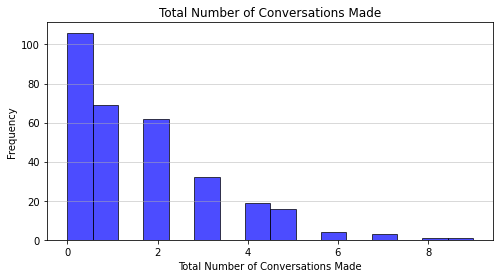

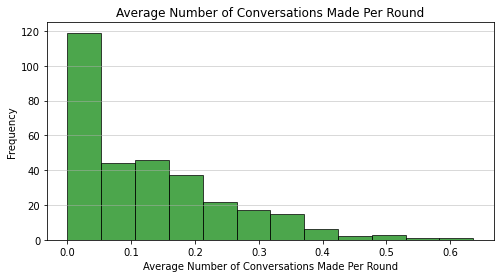

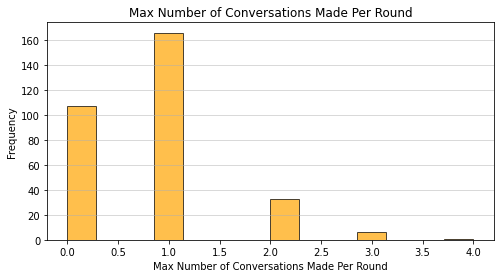

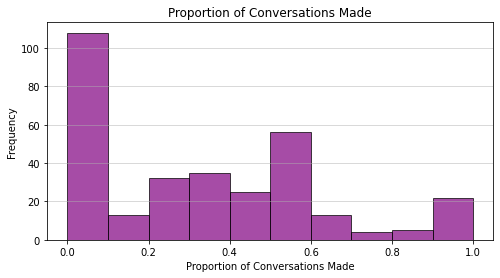

In [48]:
# How many conversations do players make total
# How many conversations do they make per round

def find_conversation_creation_for_all_games(json_file):
    all_num_conversations_made = []
    all_avg_num_conversations_made_per_round = []
    all_max_num_conversations_made_per_round = []
    all_proportion_conversations_made = []

    with open(json_file, 'r') as f:
        data = json.load(f)

        for game_id, game_data in data.items():
            players = game_data['privateInfo']['gameNames']

            chat_data = game_data['chatInfo']
            transaction_data = game_data['privateInfo']['masterTransactions']
            last_round = game_data['publicInfo']['roundNum'] - 1
            round_end_times = []
            for c_id, conversation in chat_data['conversations'].items():
                if c_id == 'global':
                    for m_id, message in conversation['messages'].items():
                        if message['runtimeType'] == 'gameNotification' or message.get('from') == 'Game':
                            round_end_times.append(convert_str_to_time(message['time']))
                    break
            if len(round_end_times) == 0:
                print(f"No round end times found for game {game_id}. Skipping.")
                continue

            round_end_times = round_end_times[:last_round]

            for player in players:
                num_conversations_made, avg_num_conversations_made_per_round, max_num_conversations_made_per_round, proportion_conversations_made = find_conversation_creation_for_player(chat_data, player, round_end_times, transaction_data, game_id=game_id)

                all_num_conversations_made.append(num_conversations_made)
                all_avg_num_conversations_made_per_round.append(avg_num_conversations_made_per_round)
                all_max_num_conversations_made_per_round.append(max_num_conversations_made_per_round)
                all_proportion_conversations_made.append(proportion_conversations_made)

        display_charts(all_num_conversations_made, all_avg_num_conversations_made_per_round, all_max_num_conversations_made_per_round, all_proportion_conversations_made)

def find_conversation_creation_for_player(chat_data, player_name, round_end_times, transaction_data, game_id=None):
    num_conversations_in = 0
    num_conversations_made = 0
    num_conversations_made_per_round = [0 for _ in range(len(round_end_times))]

    for c_id, conversation in chat_data['conversations'].items():
        if c_id == 'global':
            continue
        
        if player_name in conversation['participants']:
            num_conversations_in += 1

            if 'messages' not in conversation:
                print(f"No messages found for conversation {c_id}. Skipping.")
                break          

            player_made_conversation = False
            if conversation['participants'][0] == player_name:
                num_conversations_made += 1
                player_made_conversation = True

            round = 1
            round_started_in = 0

            for m_id, message in conversation['messages'].items():
                if round > len(round_end_times):
                    break  # message sent after the last round, ignore
                while convert_str_to_time(message['time']) >= round_end_times[round-1]:
                    round += 1
                    if round > len(round_end_times):
                        break  # message sent after the last round, ignore
                if round > len(round_end_times):
                    break  # message sent after the last round, ignore

                if round_started_in == 0:
                    round_started_in = round
                    if player_made_conversation:
                        num_conversations_made_per_round[round - 1] += 1
                    break

    avg_num_conversations_made_per_round = sum(num_conversations_made_per_round) / len(num_conversations_made_per_round) if num_conversations_made_per_round else 0
    max_num_conversations_made_per_round = max(num_conversations_made_per_round)
    proportion_conversations_made = num_conversations_made / num_conversations_in if num_conversations_in > 0 else 0
        
    return num_conversations_made, avg_num_conversations_made_per_round, max_num_conversations_made_per_round, proportion_conversations_made


def display_charts(all_num_conversations_made, all_avg_num_conversations_made_per_round, all_max_num_conversations_made_per_round, all_proportion_conversations_made):
    import matplotlib.pyplot as plt

    vars_to_plot = [
        (all_num_conversations_made, 'Total Number of Conversations Made'),
        (all_avg_num_conversations_made_per_round, 'Average Number of Conversations Made Per Round'),
        (all_max_num_conversations_made_per_round, 'Max Number of Conversations Made Per Round'),
        (all_proportion_conversations_made, 'Proportion of Conversations Made'),
    ]

    colors = ['blue','green','orange','purple']
    for (data, title), color in zip(vars_to_plot, colors):
        if not data:
            print(f"No data for '{title}', skipping.")
            continue

        plt.figure(figsize=(8, 4))
        plt.hist(data, bins='auto', color=color, edgecolor='black', alpha=0.7)
        plt.title(title)
        plt.xlabel(title)
        plt.ylabel('Frequency')
        plt.grid(axis='y', alpha=0.6)
        plt.show()
    
find_conversation_creation_for_all_games('preprod_filtered.json')